# Prerequist of learning NeRF

## Camera Model Overview

A typical camera cmodel can be represented using a pinhole camera model, where the world scene is projected onto a 2D image plane through a pinhole at the center of the lens. The camera pose is defined by its position and orientation relative to the world coordinate system. As shown in the figure, $Y/Z=y/f$

![pinhole_model](figures/pinhole%20model.png)

Given the world coordinate of object $[X,Y,Z]$ and its distance from the pinhole $Z$, the distance between the pinhole and the image plane $f$, the pixel coordinate can be derived by using the triangles argument. 

$$
\begin{bmatrix}
x \\ y\\ z \\
\end{bmatrix}=
\begin{bmatrix}
fX/Z \\ fY/Z \\ f \\
\end{bmatrix}=
\begin{bmatrix}
f &  & & 0\\
 & f &  & 0\\
 &  & 1  & 0\\
\end{bmatrix}
\begin{bmatrix}
X \\ Y \\ Z \\ 1\\
\end{bmatrix}=diga(f,f,1)[I|0] \bold{X}
$$

A principle point $(p_x,p_y)$ is the intersection location of the image plane with the principal axis. The above example assume this principle point is at (0,0). If it is not, the equation expressed in homoegenous coordinates are:
$$
\begin{bmatrix}
fX \\ fY \\ Z \\
\end{bmatrix}=
\begin{bmatrix}
f &  & p_x & 0\\
 & f & p_y & 0\\
 &  & 1  & 0\\
\end{bmatrix}
\begin{bmatrix}
X \\ Y \\ Z \\ 1\\
\end{bmatrix}=K[I|0]
\begin{bmatrix}
X \\ Y \\ Z \\ 1\\
\end{bmatrix}
$$

### camera rotation and translation
![pinhole_model](figures//pinhole%20model%202.png)

Say camera center in Cartesian coordinates is $\tilde C$ and that camera rotation $R$. We can transform a Cartesian point $\tilde{\bold{X}}$ in the world coordinate system to a Cartesian point $\bold{\tilde{X}_{cam}}$ in the camera coordinates system as:
$$
\bold{\tilde{X}_{cam}}=\bold{R}(\tilde{\bold{X}}-\tilde{\bold{C}}) =
\begin{bmatrix}
\bold{R} & -\bold{R\tilde{C}} \\
0 & 1\\
\end{bmatrix}
\begin{bmatrix}X \\Y\\Z\\1\end{bmatrix}
$$
Denote $\bold{t}=-\bold{R\tilde{C}}$. We can see the final image coordinate is:
$$
x=\bold{K[R|t]X}
$$

$\bold{K}$ is intrinsics matrix which describe the internal parameters of the camera that relate the 3D world coordinates to 2D image coordinates. It constains focal length, principal point and pixel aspect ratio (1 if pixels are square)

$\bold{[R|t]}$ is the extrinsic matrix which desribes the transformation from world coordinates to camera coordinates.

### Example from NeRF public dataset: lego

You can search nerf_synthetic.zip file on internet and unzip to your folder. 

In [ ]:
import torch
import numpy as np
import json
import os
from PIL import Image
import matplotlib.pyplot as plt
import cv2

# data path
base_dir = "../datasets/nerf_synthetic/lego"
# reduce the resolution by factor
factor = 4
# load camera intrinsic and extrinsic parameters from json file
with open(os.path.join(base_dir, 'transforms_{}.json'.format('train')), 'r') as fp:
    meta = json.load(fp)
images = []
cams = []
for i in range(len(meta['frames'])):
    frame = meta['frames'][0]
    fname = os.path.join(base_dir, frame['file_path'] + '.png')
    with open(fname, 'rb') as imgin:
        image = np.array(Image.open(imgin), dtype=np.float32) / 255.
        if factor >= 2:
            [halfres_h, halfres_w] = [hw // factor for hw in image.shape[:2]]
            image = cv2.resize(
                image, (halfres_w, halfres_h), interpolation=cv2.INTER_AREA)
    cams.append(np.array(frame['transform_matrix'], dtype=np.float32))
    images.append(image)
images = np.stack(np.array(images), axis=0)
print('Number of images, width, height, channels:', images.shape)

Number of images, width, height, channels: (100, 400, 400, 4)


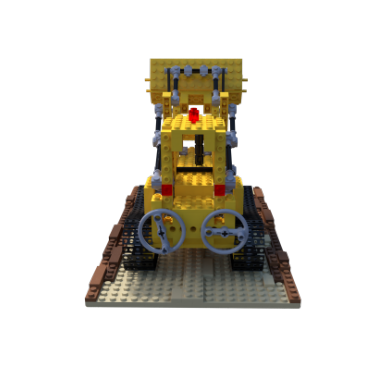

In [2]:
plt.imshow(images[0,:,:,:])
plt.axis('off')
plt.show()

In [3]:
print('Camera extrinsic matrices shape:', np.array(cams).shape)

Camera extrinsic matrices shape: (100, 4, 4)


In [4]:
H, W = images.shape[1:3]
cam_to_world=cams[0]
camera_angle_x=float(meta['camera_angle_x']) # angle of field of view in x direction
focal = .5 * W / np.tan(.5 * camera_angle_x)
n_poses=images.shape[0]
print('Focal length:', focal)
print('Number of poses:', n_poses) 
print('Image height:', H)
print('Image width:', W)
print('Camera to world matrix ([R|t], extrinsic matrix) of first image:\n', cam_to_world)
print('Camera view of angle x (degree):', camera_angle_x*180/np.pi)

Focal length: 555.5555155968841
Number of poses: 100
Image height: 400
Image width: 400
Camera to world matrix ([R|t], extrinsic matrix) of first image:
 [[-9.9990219e-01  4.1922452e-03 -1.3345719e-02 -5.3798322e-02]
 [-1.3988681e-02 -2.9965907e-01  9.5394367e-01  3.8454704e+00]
 [-4.6566129e-10  9.5403719e-01  2.9968831e-01  1.2080823e+00]
 [ 0.0000000e+00  0.0000000e+00  0.0000000e+00  1.0000000e+00]]
Camera view of angle x (degree): 39.597755335771296


### Genrate rays for NeRF training
First, we calcaulte all pixel's world coordinates and the its direction from the camera center.

Optionally, we can calculate the distance from each unit-norm direction vector to its x-axis neighbor which is used for MipNeRF as Radiance for conical frustum

In [5]:
near= 2.0 # object in the scene is between near and far plane
far= 6.0
x, y = np.meshgrid(
    np.arange(W, dtype=np.float32),  # X-Axis (columns)
    np.arange(H, dtype=np.float32),  # Y-Axis (rows)
    indexing='xy')

camera_directions = np.stack(
    [(x - W * 0.5 + 0.5) / focal,
    -(y - H * 0.5 + 0.5) / focal,
    -np.ones_like(x)],
    axis=-1) # 400x400x3

In [6]:
# Rotate ray directions from camera frame to the world frame
directions = ((camera_directions[..., None, :] * cam_to_world[None, None, :3, :3]).sum(axis=-1))  # Translate camera frame's origin to the world frame
origins = np.broadcast_to(cam_to_world[None, None, :3, -1], directions.shape)
viewdirs = directions / np.linalg.norm(directions, axis=-1, keepdims=True)
print(origins.shape, directions.shape, viewdirs.shape)

(400, 400, 3) (400, 400, 3) (400, 400, 3)


In [14]:
print(origins[0,0,:])
print(directions[0,0,:])

[-0.05379832  3.8454704   1.2080823 ]
[ 0.37391606 -1.05652792  0.04290647]


In [15]:
# For MipNeRF, we need to calculate the radii for each ray
# Distance from each unit-norm direction vector to its x-axis neighbor
dx = np.sqrt(np.sum((directions[:-1, :, :] - directions[1:, :, :]) ** 2, -1))
dx = np.concatenate([dx, dx[-2:-1, :]], 0)

# Cut the distance in half, and then round it out so that it's
# halfway between inscribed by / circumscribed about the pixel.
radii = dx * 2 / np.sqrt(12)

In [16]:
radii.shape

(400, 400)

In [17]:
radii[0:5,0:5]

array([[0.00103923, 0.00103923, 0.00103923, 0.00103923, 0.00103923],
       [0.00103923, 0.00103923, 0.00103923, 0.00103923, 0.00103923],
       [0.00103923, 0.00103923, 0.00103923, 0.00103923, 0.00103923],
       [0.00103923, 0.00103923, 0.00103923, 0.00103923, 0.00103923],
       [0.00103923, 0.00103923, 0.00103923, 0.00103923, 0.00103923]])